In [1]:
import pandas as pd
import numpy as np
import sys

def exit_with_error(message):
    print(f"Error: {message}")
    sys.exit(1)

metadata_fname = "metadata/metadata_wide.tsv"
quants_fname = "data/proteins_normalized_wide.tsv"

metadata = pd.read_csv(metadata_fname, sep='\t', na_values=['NA'])
data = pd.read_csv(quants_fname, sep='\t')
data = data.fillna(0)
protein_names = data['protein'].values

print("Metadata shape:", metadata.shape)
print("Data shape:", data.shape)

Metadata shape: (104, 25)
Data shape: (2575, 105)


Data shape: (86, 2575)
Months: [22.42 14.37 14.37 17.36 11.15  5.85 22.42 29.33 22.42 20.48 17.46  5.85
 14.37  8.15 11.15 22.42 30.25 27.   14.37 20.48  5.85  5.85 27.   17.46
 29.33 11.15 20.48  8.15  8.15 17.46 20.58 11.15 27.   22.42 17.46 11.15
 14.37  5.85  8.15 29.33  8.15 22.42 27.   22.42  5.85 11.15  5.85 22.42
 17.46 30.25 20.48  5.85 20.58 17.36  8.15 14.37  8.15 11.15 14.37 22.42
 17.46  8.15 11.15  5.85 22.42 14.37  5.85 20.48 20.48 27.   20.48 17.46
  8.15 29.33 11.15 22.42 20.48 27.   14.37 30.25 14.37 17.36  8.15 11.15
 27.   22.42]
Sex: [0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1 1 0
 1 1 0 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0
 0 1 0 0 0 1 1 1 0 1 1 1]


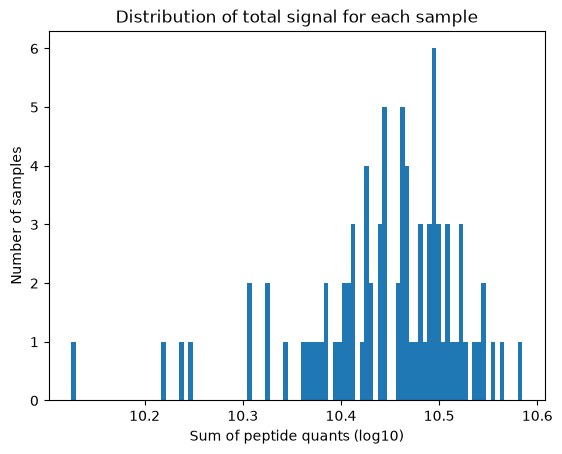

In [2]:
import matplotlib.pyplot as plt

valid_replicates = metadata[metadata['Age_months'].notna()]['replicate'].tolist()

X = []
month = []
sex = []

for idx in valid_replicates:
  for sample in data.columns[:]:
    if idx in sample:
      s_month = metadata[metadata['replicate'] == idx]['Age_months'].values[0]
      s_sex = metadata[metadata['replicate'] == idx]['Sex'].values[0]

      month.append(s_month)
      sex.append(s_sex)
      X.append(data[sample].values)

X = np.array(X)
X = np.power(2, X) # "unlog" X

month = np.array(month)
month = month.astype(float)

sex = np.array(sex)
sex = np.where(sex == "Male", 0, 1) # encode the sex array
sex = sex.astype(int)

print("Data shape:", X.shape)
print("Months:", month)
print("Sex:", sex)

total_signal = np.sum(X, axis=1)
plt.hist(np.log10(total_signal), bins = 100)
plt.title('Distribution of total signal for each sample')
plt.ylabel('Number of samples')
plt.xlabel('Sum of peptide quants (log10)')
plt.show()

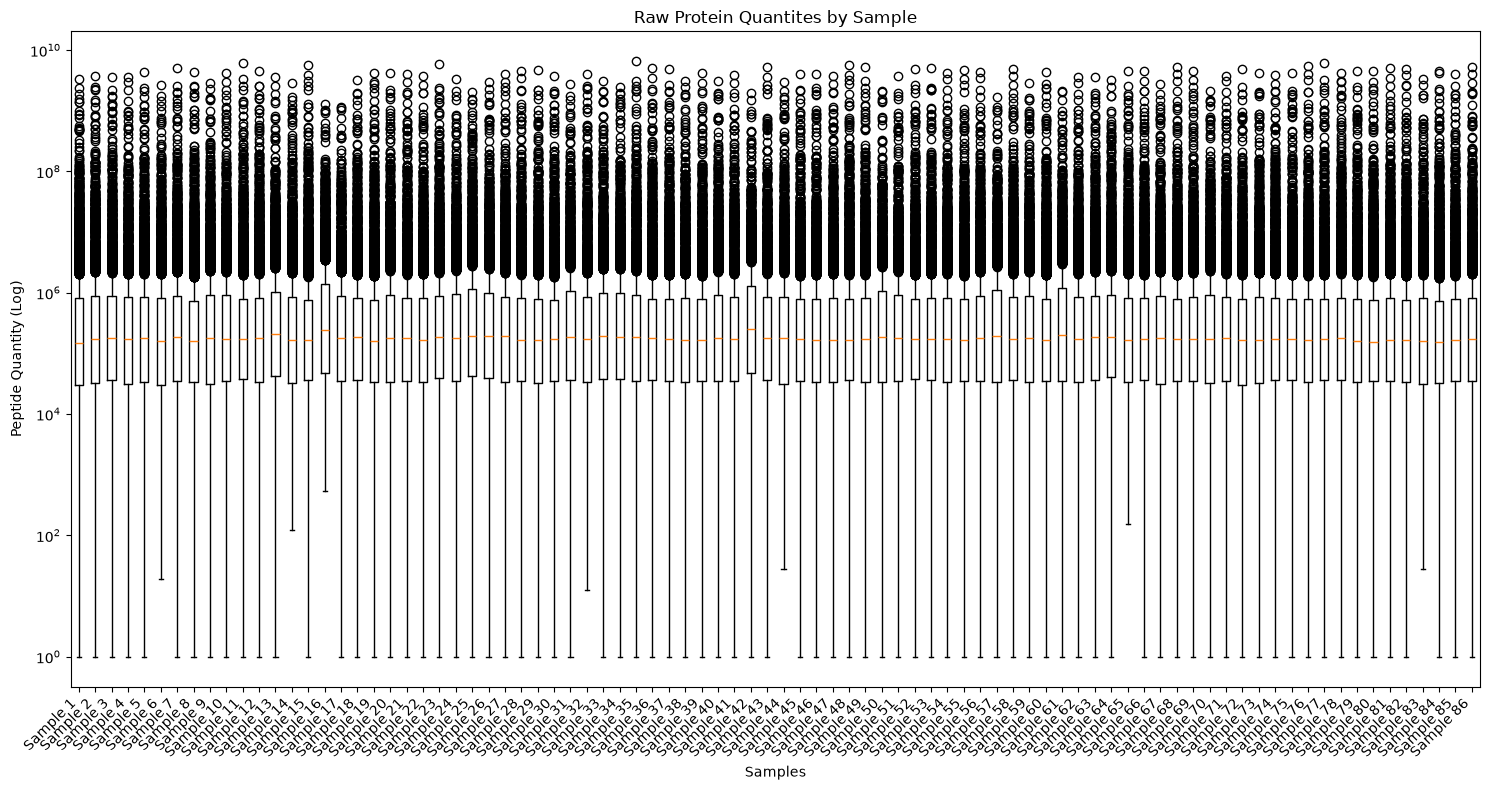

In [3]:
# Create the box plot
plt.figure(figsize=(15, 8))
plt.boxplot(X.T)  # Transpose the data

plt.title('Raw Protein Quantites by Sample')
plt.xlabel('Samples')
plt.ylabel('Peptide Quantity (Log)')
plt.xticks(range(1, X.shape[0] + 1), [f'Sample {i+1}' for i in range(X.shape[0])], rotation=45, ha='right')

# Use log scale for y-axis as peptide quantities often span several orders of magnitude
plt.yscale('log')

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# Log transformation to reduce skewness
X_log = np.log1p(X)

# Standard scaling to normalize the range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

In [5]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm


def analyze_proteins_age_sex_interaction(
    X:            np.ndarray,
    month:        np.ndarray,
    sex:          np.ndarray,
    protein_names: np.ndarray,
    alpha: float = 0.01,
) -> pd.DataFrame:
    """
    Test for (i) age-related change in each protein's abundance and
    (ii) whether that age effect differs between males and females
    using an ordinary-least-squares model with a sex × age interaction.

    Model (dummy-coded with male = 0, female = 1)
        protein ~ month * sex
                = β0 + β1·month + β2·sex[female] + β3·(month × sex[female])

    Returns one row per protein with coefficients, SEs, two p-values
    (slope in males; slope-difference interaction), BH-adjusted q-values,
    100·(1-alpha)% CIs, and significance flags.

    Parameters
    ----------
    X : (n_samples, n_proteins) array
        Protein intensities (log-scale recommended).
    month : (n_samples,) array-like
        Numeric ages in months.
    sex : (n_samples,) array-like
        Sex labels (string or 0/1). Will be treated as categorical.
    protein_names : (n_proteins,) array-like
        Names of proteins corresponding to X columns.
    alpha : float, default 0.01
        Two-sided type-I error rate used for CIs and FDR flags.

    Returns
    -------
    pandas.DataFrame
        Columns
        ────────────────
        protein
        beta_month, se_month, p_month, q_month, ci_month_low, ci_month_high
        beta_int,   se_int,   p_int,   q_int,   ci_int_low,   ci_int_high
        signif_month          (q_month  < alpha)
        signif_interaction    (q_int    < alpha)
        error  (only if a model failed)
    """
    # ─── input checks ──────────────────────────────────────────────────────
    n_samples, n_proteins = X.shape
    if len(month) != n_samples or len(sex) != n_samples:
        raise ValueError("month, sex, and X must have the same number of rows.")
    if len(protein_names) != n_proteins:
        raise ValueError("protein_names length must equal X.shape[1].")

    month = np.asarray(month, dtype=float)
    sex_cat = pd.Categorical(sex)
    zcrit = norm.ppf(1 - alpha / 2)

    rows = []

    # ─── per-protein regression ────────────────────────────────────────────
    for col_idx, pname in enumerate(protein_names):
        df = pd.DataFrame(
            {
                "protein": X[:, col_idx],
                "month":   month,
                "sex":     sex_cat,
            }
        )

        try:
            fit = smf.ols("protein ~ month * sex", data=df).fit()

            # reference category is the *first* level in sex_cat.categories
            ref_female = sex_cat.categories[1]  # will raise if only one level

            beta_month = fit.params["month"]
            se_month   = fit.bse["month"]
            p_month    = fit.pvalues["month"]

            int_term = f"month:sex[T.{ref_female}]"
            beta_int = fit.params[int_term]
            se_int   = fit.bse[int_term]
            p_int    = fit.pvalues[int_term]

            rows.append(
                dict(
                    protein=pname,

                    beta_month=beta_month,
                    se_month=se_month,
                    p_month=p_month,
                    ci_month_low=beta_month - zcrit * se_month,
                    ci_month_high=beta_month + zcrit * se_month,

                    beta_int=beta_int,
                    se_int=se_int,
                    p_int=p_int,
                    ci_int_low=beta_int - zcrit * se_int,
                    ci_int_high=beta_int + zcrit * se_int,
                )
            )

        except Exception as err:
            rows.append(
                dict(
                    protein=pname,

                    beta_month=np.nan,
                    se_month=np.nan,
                    p_month=np.nan,
                    ci_month_low=np.nan,
                    ci_month_high=np.nan,

                    beta_int=np.nan,
                    se_int=np.nan,
                    p_int=np.nan,
                    ci_int_low=np.nan,
                    ci_int_high=np.nan,

                    error=str(err),
                )
            )

    results = pd.DataFrame(rows)

    # ─── multiple-test correction (BH) ─────────────────────────────────────
    for p_col, q_col in (("p_month", "q_month"), ("p_int", "q_int")):
        ok = results[p_col].notna()
        if ok.any():
            results.loc[ok, q_col] = multipletests(
                results.loc[ok, p_col], method="fdr_bh"
            )[1]

    results[f"signif_month"] = results["q_month"] < alpha
    results[f"signif_interaction"] = results["q_int"] < alpha

    # sort with most significant interaction first
    results = results.sort_values("p_int", na_position="last")

    return results


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.text import Text


def _text_bbox(ann, renderer):
    """Return the bounding box of the annotation's text only, excluding the arrow."""
    return Text.get_window_extent(ann, renderer)


def _boxes_overlap(b1, b2, pad=2.0):
    """Return True if two bounding boxes (in display coords) overlap, with optional padding."""
    return not (
        b1.x1 + pad < b2.x0 - pad
        or b1.x0 - pad > b2.x1 + pad
        or b1.y1 + pad < b2.y0 - pad
        or b1.y0 - pad > b2.y1 + pad
    )


def _box_overlaps_point(bbox, px, py, radius, pad=2.0):
    """Return True if a bounding box overlaps a circular data point."""
    closest_x = max(bbox.x0 - pad, min(px, bbox.x1 + pad))
    closest_y = max(bbox.y0 - pad, min(py, bbox.y1 + pad))
    return (closest_x - px) ** 2 + (closest_y - py) ** 2 < radius ** 2


def _segment_intersects_rect(x1, y1, x2, y2, rect, pad=2.0):
    """
    Return True if the line segment (x1,y1)→(x2,y2) intersects the
    axis-aligned rectangle *rect* (a Bbox), expanded by *pad* pixels.

    Uses the Liang–Barsky algorithm: parameterise the segment as
    P(t) = P1 + t*(P2-P1) for t in [0,1] and clip against each edge.
    If a valid t-interval remains after all four clips, the segment
    intersects the rectangle.
    """
    rx0 = rect.x0 - pad
    ry0 = rect.y0 - pad
    rx1 = rect.x1 + pad
    ry1 = rect.y1 + pad

    dx = x2 - x1
    dy = y2 - y1

    # p, q pairs for the four rectangle edges
    # left, right, bottom, top
    p = [-dx, dx, -dy, dy]
    q = [x1 - rx0, rx1 - x1, y1 - ry0, ry1 - y1]

    t_enter = 0.0
    t_exit = 1.0

    for pi, qi in zip(p, q):
        if pi == 0:
            # Segment is parallel to this edge
            if qi < 0:
                return False  # outside and parallel → no intersection
            # else: inside this slab, continue
        else:
            t = qi / pi
            if pi < 0:
                # Entering edge
                t_enter = max(t_enter, t)
            else:
                # Exiting edge
                t_exit = min(t_exit, t)
            if t_enter > t_exit:
                return False

    return True


def _arrow_crosses_labels(ann, placed_annotations, renderer, pad=2.0):
    """
    Check whether the arrow from ann's text position to its data point
    passes through any placed label's text bounding box.

    Returns the index of the first placed annotation whose text bbox
    is crossed, or None if the arrow is clear.
    """
    # Arrow endpoints in display coordinates:
    #   - start: the text position (center-bottom of text bbox)
    #   - end:   the data point
    pt_disp = ann.axes.transData.transform(ann.xy)
    text_bb = _text_bbox(ann, renderer)
    # Use the center of the edge of the text bbox closest to the data point
    # as the arrow start. A reasonable approximation is the bbox center.
    tx = (text_bb.x0 + text_bb.x1) / 2.0
    ty = (text_bb.y0 + text_bb.y1) / 2.0
    dx, dy = pt_disp

    for i, other in enumerate(placed_annotations):
        other_bb = _text_bbox(other, renderer)
        if _segment_intersects_rect(tx, ty, dx, dy, other_bb, pad=pad):
            return i
    return None


def _arrow_of_other_crosses_bbox(target_bb, placed_annotations, renderer, pad=2.0):
    """
    Check whether any placed annotation's arrow (from its text to its data
    point) passes through *target_bb*.

    Returns the index of the first offending placed annotation, or None.
    """
    for i, other in enumerate(placed_annotations):
        other_pt = other.axes.transData.transform(other.xy)
        other_text_bb = _text_bbox(other, renderer)
        ox = (other_text_bb.x0 + other_text_bb.x1) / 2.0
        oy = (other_text_bb.y0 + other_text_bb.y1) / 2.0
        if _segment_intersects_rect(ox, oy, other_pt[0], other_pt[1],
                                    target_bb, pad=pad):
            return i
    return None


def _try_place_single(
    fig,
    ax,
    ann,
    placed_annotations,
    point_display_coords,
    marker_radius_px,
    ax_bbox,
    angles,
    start_radius_px,
    max_radius_px,
    radius_step_px,
    renderer,
    check_arrows=True,
    verbose=False,
    depth=0,
):
    """
    Try to place a single annotation by sweeping radially outward.

    Returns
    -------
    success : bool
        Whether a valid position was found. If True, ann.xytext is set to
        the winning offset (in offset-pixels from the data point).
    most_conflicted : annotation object or None
        The already-placed label that blocked this one most often across the
        entire sweep. None if no label conflicts were recorded (e.g. only
        data-point or axes-boundary failures).
    """
    pt_disp = ax.transData.transform(ann.xy)
    px, py = pt_disp
    label = ann.get_text()
    indent = "  " * depth

    conflict_counts = {}  # placed annotation -> number of times it blocked us
    exhausted_angles = set()

    radius = start_radius_px
    while radius <= max_radius_px:
        if verbose:
            print(f"{indent}  Trying radius={radius:.0f}px...")

        for angle_deg in angles:
            if angle_deg in exhausted_angles:
                if verbose:
                    print(
                        f"{indent}    angle={angle_deg:.0f}° — SKIP (previously outside axes)"
                    )
                continue

            angle_rad = np.deg2rad(angle_deg)
            offset_x = radius * np.cos(angle_rad)
            offset_y = radius * np.sin(angle_rad)

            # Set the text offset in pixels from the data point
            ann.xyann = (offset_x, offset_y)

            # Get text-only bounding box (excludes arrow) using the renderer
            bb = _text_bbox(ann, renderer)

            # Test 1: inside axes
            inside = (
                ax_bbox.x0 <= bb.x0
                and bb.x1 <= ax_bbox.x1
                and ax_bbox.y0 <= bb.y0
                and bb.y1 <= ax_bbox.y1
            )
            if not inside:
                exhausted_angles.add(angle_deg)
                if verbose:
                    print(
                        f"{indent}    angle={angle_deg:.0f}° — FAIL (outside axes, will not retry)"
                    )
                continue

            # Test 2: overlaps already-placed labels — recompute text bboxes fresh
            placed_bboxes = [_text_bbox(a, renderer) for a in placed_annotations]
            overlapping_label = next(
                (
                    i
                    for i, placed_bb in enumerate(placed_bboxes)
                    if _boxes_overlap(bb, placed_bb)
                ),
                None,
            )
            if overlapping_label is not None:
                conflicting_ann = placed_annotations[overlapping_label]
                conflict_counts[conflicting_ann] = (
                    conflict_counts.get(conflicting_ann, 0) + 1
                )
                if verbose:
                    print(
                        f"{indent}    angle={angle_deg:.0f}° — FAIL "
                        f"(overlaps label '{conflicting_ann.get_text()}')"
                    )
                continue

            # Test 3: overlaps ANY data point (including the annotation's own)
            overlapping_point = next(
                (
                    i
                    for i, (dpx, dpy) in enumerate(point_display_coords)
                    if _box_overlaps_point(bb, dpx, dpy, marker_radius_px)
                ),
                None,
            )
            if overlapping_point is not None:
                if verbose:
                    print(
                        f"{indent}    angle={angle_deg:.0f}° — FAIL "
                        f"(overlaps data point {overlapping_point})"
                    )
                continue

            # Test 4: this annotation's arrow crosses a placed label's text
            if check_arrows:
                crossed = _arrow_crosses_labels(ann, placed_annotations, renderer)
                if crossed is not None:
                    if verbose:
                        crossed_name = placed_annotations[crossed].get_text()
                        print(
                            f"{indent}    angle={angle_deg:.0f}° — FAIL "
                            f"(arrow crosses label '{crossed_name}')"
                        )
                    continue

            # Test 5: a placed annotation's arrow crosses this label's text
            if check_arrows:
                crosser = _arrow_of_other_crosses_bbox(
                    bb, placed_annotations, renderer
                )
                if crosser is not None:
                    if verbose:
                        crosser_name = placed_annotations[crosser].get_text()
                        print(
                            f"{indent}    angle={angle_deg:.0f}° — FAIL "
                            f"(arrow of '{crosser_name}' crosses this label)"
                        )
                    continue

            # All tests passed — ann.xyann is already set to this offset
            if verbose:
                arrow_note = "" if check_arrows else " [arrow-crossing allowed]"
                print(
                    f"{indent}    angle={angle_deg:.0f}° — OK "
                    f"(radius={radius:.0f}px, angle={angle_deg:.0f}°){arrow_note}"
                )
            return True, None

        # If all angles are exhausted there is no point increasing the radius
        if len(exhausted_angles) == len(angles):
            if verbose:
                print(
                    f"{indent}  -> All angles exhausted (outside axes), giving up early"
                )
            break

        radius += radius_step_px

    # Return the label that blocked us the most across the entire sweep
    most_conflicted = (
        max(conflict_counts, key=conflict_counts.get) if conflict_counts else None
    )
    return False, most_conflicted


def _place_labels(
    fig,
    ax,
    annotations,
    data_coords,
    marker_radius_px,
    start_radius_px=30.0,
    max_radius_px=200.0,
    radius_step_px=10.0,
    angle_step_deg=10.0,
    start_angle_deg=80.0,
    max_backtrack_depth=3,
    verbose=False,
):
    """
    Place each annotation by sweeping radially outward from its data point,
    with backtracking up to max_backtrack_depth if placement fails.

    Parameters
    ----------
    data_coords : np.ndarray, shape (N, 2)
        Data coordinates (not display) of ALL scatter points. Display
        coordinates are computed internally after the initial draw so they
        are always fresh.
    start_radius_px : float
        Initial search radius in pixels.
    max_radius_px : float
        Maximum search radius in pixels before giving up.
    radius_step_px : float
        Pixel increment between radius attempts.
    angle_step_deg : float
        Angular step size in degrees for the radial sweep.
    start_angle_deg : float
        Starting angle in degrees (90 = directly above the point).
    max_backtrack_depth : int
        How many times placement can recursively displace an earlier label.
    verbose : bool
        Print detailed placement decisions.
    """
    # Do one full draw so all transforms and extents are up to date,
    # then grab the renderer for lightweight bbox queries.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    ax_bbox = ax.get_window_extent(renderer)

    # Compute display coordinates AFTER the draw so they match the
    # current axes transform exactly.
    point_display_coords = ax.transData.transform(data_coords)

    placed_annotations = []
    angles = np.arange(start_angle_deg, start_angle_deg + 360, angle_step_deg)

    def attempt_placement(ann, placed, depth):
        """
        Recursively attempt to place ann, backtracking up to max_backtrack_depth.

        Returns True if ann was successfully placed (and placed list is updated).
        ann.xyann is set to the winning offset before returning True.

        Strategy: first sweep with arrow-crossing checks enabled. If that
        fails, sweep again allowing arrows to cross other labels.
        """
        label = ann.get_text()
        indent = "  " * depth

        # Reset to zero offset (text sits on data point) before searching
        ann.xyann = (0, 0)

        if verbose:
            print(f"\n{indent}Placing '{label}' (depth={depth})...")

        # --- Pass 1: strict (arrows must not cross labels) ----------------
        success, most_conflicted = _try_place_single(
            fig,
            ax,
            ann,
            placed,
            point_display_coords,
            marker_radius_px,
            ax_bbox,
            angles,
            start_radius_px,
            max_radius_px,
            radius_step_px,
            renderer,
            check_arrows=True,
            verbose=verbose,
            depth=depth,
        )

        if success:
            placed.append(ann)
            return True

        # --- Pass 2: relaxed (allow arrows to cross labels) ---------------
        if verbose:
            print(f"{indent}  -> Retrying '{label}' with arrow-crossing allowed...")

        ann.xyann = (0, 0)

        success, most_conflicted = _try_place_single(
            fig,
            ax,
            ann,
            placed,
            point_display_coords,
            marker_radius_px,
            ax_bbox,
            angles,
            start_radius_px,
            max_radius_px,
            radius_step_px,
            renderer,
            check_arrows=False,
            verbose=verbose,
            depth=depth,
        )

        if success:
            placed.append(ann)
            return True

        # Placement failed
        if depth >= max_backtrack_depth or most_conflicted is None:
            if verbose:
                print(
                    f"{indent}  -> Could not place '{label}' "
                    f"(depth limit reached or no label conflicts recorded)"
                )
            return False

        if verbose:
            print(
                f"{indent}  -> Backtracking: removing '{most_conflicted.get_text()}' "
                f"(most conflicting) to make room for '{label}'"
            )

        # Save the displaced label's current (good) position so we can
        # restore it if backtracking fails.
        saved_offset = most_conflicted.xyann

        # Remove the most conflicting label and retry current label
        placed.remove(most_conflicted)

        success_now, _ = _try_place_single(
            fig,
            ax,
            ann,
            placed,
            point_display_coords,
            marker_radius_px,
            ax_bbox,
            angles,
            start_radius_px,
            max_radius_px,
            radius_step_px,
            renderer,
            check_arrows=False,
            verbose=verbose,
            depth=depth,
        )

        if not success_now:
            # Still can't place even without the conflicting label — restore and give up
            if verbose:
                print(
                    f"{indent}  -> Still failed after removing "
                    f"'{most_conflicted.get_text()}', restoring it"
                )
            most_conflicted.xyann = saved_offset
            placed.append(most_conflicted)
            return False

        # Current label placed successfully — ann.xyann set by _try_place_single
        placed.append(ann)

        if verbose:
            print(
                f"{indent}  -> '{label}' placed, now re-attempting "
                f"'{most_conflicted.get_text()}'"
            )

        # Reset displaced label to zero offset before retrying
        most_conflicted.xyann = (0, 0)

        success_displaced = attempt_placement(most_conflicted, placed, depth + 1)

        if not success_displaced:
            if verbose:
                print(
                    f"{indent}  -> Could not re-place '{most_conflicted.get_text()}' "
                    f"— it will be skipped"
                )
            most_conflicted.set_visible(False)
            print(
                f"Warning: could not place label '{most_conflicted.get_text()}' "
                f"after backtracking — skipping."
            )

        return True

    for ann in annotations:
        if not attempt_placement(ann, placed_annotations, depth=0):
            ann.set_visible(False)
            print(
                f"Warning: could not place label '{ann.get_text()}' "
                f"without overlap — skipping."
            )

    return annotations


def short_protein_label(name):
    """Reduce a UniProt-style id to just the protein name.

    e.g. 'sp|Q8CGN5|PLIN1_MOUSE' -> 'PLIN1', 'tr|A2CEK7|A2CEK7_MOUSE' -> 'A2CEK7'.
    Protein groups joined by ' / ' are reduced member-by-member.
    """
    labels = []
    for member in str(name).split(' / '):
        parts = member.split('|')
        entry = parts[2] if len(parts) >= 3 else member  # e.g. PLIN1_MOUSE
        labels.append(entry.split('_')[0])  # strip the _MOUSE species suffix
    return ' / '.join(labels)


def create_interaction_volcano_plot(
    results_df,
    alpha: float = 0.01,
    top_n: int = 10,
    save_path: str | None = None,
    start_radius_px: float = 30.0,
    max_radius_px: float = 200.0,
    radius_step_px: float = 10.0,
    angle_step_deg: float = 10.0,
    max_backtrack_depth: int = 3,
    verbose: bool = False,
):
    """
    Volcano plot for the sex × age interaction term.

    Parameters
    ----------
    results_df : pandas.DataFrame
        Must contain 'beta_int', 'q_int', 'protein', 'signif_interaction'.
    alpha : float
        FDR threshold for the reference line.
    top_n : int
        Number of top points to label (by -log10(q_int)).
    save_path : str | None
        Save path; if None the plot is shown interactively.
    start_radius_px : float
        Initial label distance from data point in pixels.
    max_radius_px : float
        Maximum label distance before giving up on a label.
    radius_step_px : float
        Pixel increment when increasing search radius.
    angle_step_deg : float
        Angular step size in degrees for the radial sweep.
    max_backtrack_depth : int
        How many times placement can recursively displace an earlier label.
    verbose : bool
        Print detailed placement decisions.

    Returns
    -------
    matplotlib.figure.Figure
    """
    if results_df.empty:
        print("No results to visualise.")
        return None

    # ------------------------------------------------------------------ cols
    beta_col = "beta_int"
    qcol = "q_int"
    prot_col = "protein"

    sig_cols = [c for c in results_df.columns if c.startswith("signif_interaction")]
    if not sig_cols:
        raise ValueError("Column with interaction significance flag not found.")
    sig_flag = sig_cols[0]

    # ------------------------------------------------------------------ data
    df = results_df.copy()
    df["minus_log10_qint"] = -np.log10(df[qcol].replace(0, 1e-300))

    sig_df = df[df[sig_flag]]
    nonsig_df = df[~df[sig_flag]]

    # ------------------------------------------------------------------ plot
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.scatter(
        nonsig_df[beta_col],
        nonsig_df["minus_log10_qint"],
        s=20,
        alpha=0.6,
        label="Not significant (FDR)",
    )
    ax.scatter(
        sig_df[beta_col],
        sig_df["minus_log10_qint"],
        s=20,
        alpha=0.9,
        label="Significant (FDR)",
    )
    ax.axhline(-np.log10(alpha), ls="--", color="grey", alpha=0.2, label=f"FDR = {alpha:g}")

    # ------------------------------------------------------------------ labels
    top_hits = df.nlargest(top_n, "minus_log10_qint")

    ax.margins(0.15)
    plt.tight_layout()

    # Create annotations using "offset pixels" so xytext is a pixel offset
    # from the data point. Initial offset (0, 0) puts text on the point.
    annotations = [
        ax.annotate(
            short_protein_label(row[prot_col]),
            xy=(row[beta_col], row["minus_log10_qint"]),
            xytext=(0, 0),
            textcoords="offset pixels",
            fontsize=10.5,
            arrowprops=dict(arrowstyle="->", lw=0.5, color="gray"),
            ha="center",
            va="bottom",
        )
        for _, row in top_hits.iterrows()
    ]

    # Pass raw data coordinates; _place_labels will convert to display coords
    # after its initial draw() call so they are always in sync.
    all_data_coords = np.column_stack(
        [df[beta_col].values, df["minus_log10_qint"].values]
    )

    marker_radius_px = np.sqrt(20 / np.pi) * (fig.dpi / 72)

    _place_labels(
        fig,
        ax,
        annotations,
        all_data_coords,
        marker_radius_px,
        start_radius_px=start_radius_px,
        max_radius_px=max_radius_px,
        radius_step_px=radius_step_px,
        angle_step_deg=angle_step_deg,
        max_backtrack_depth=max_backtrack_depth,
        verbose=verbose,
    )

    # ------------------------------------------------------------------ cosmetics
    ax.set_xlabel("Interaction effect (Δ slope female – male)", fontsize=20)
    ax.set_ylabel("-log10(FDR-adjusted p-value for interaction)", fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(loc='upper left', fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    else:
        plt.show()

    return fig

In [7]:
# Analyze proteins
results = analyze_proteins_age_sex_interaction(X_scaled, month, sex, protein_names)

# Print top results
alpha = 0.01  # must match the α you used in the model

# Proteins whose age slope is significant *and* whose slope differs by sex
age_and_sex_specific = results[
    (results['q_month'] < alpha) &   # significant age effect
    (results['q_int']   < alpha)     # significant interaction
].copy()

# Optional: add the female slope for clearer interpretation
age_and_sex_specific['beta_month_female'] = (
    age_and_sex_specific['beta_month'] + age_and_sex_specific['beta_int']
)

# Show top 10 by the strongest interaction (smallest q_int)
top10 = age_and_sex_specific.sort_values('q_int').head(10)

print("Top 10 proteins with age-related change that differs by sex:")
print(
    top10[
        [
            'protein',
            'beta_month',         # slope in males (reference sex)
            'beta_month_female',  # slope in females
            'beta_int',           # slope difference (female − male)
            'q_month',            # FDR for age effect
            'q_int',              # FDR for interaction
        ]
    ]
)

Top 10 proteins with age-related change that differs by sex:
                                            protein  beta_month  \
2457                         tr|A2CEK7|A2CEK7_MOUSE   -0.087170   
2501                         tr|E9QA79|E9QA79_MOUSE   -0.084176   
392   sp|P11588|MUP1_MOUSE / tr|A9R9W0|A9R9W0_MOUSE   -0.080859   
169                            sp|O55189|AMBN_MOUSE    0.092563   
393                            sp|P11589|MUP2_MOUSE   -0.074810   

      beta_month_female  beta_int   q_month     q_int  
2457           0.011874  0.099044  0.000004  0.000303  
2501           0.012198  0.096374  0.000007  0.000576  
392            0.008438  0.089297  0.000008  0.001786  
169           -0.023385 -0.115948  0.000183  0.002508  
393           -0.000148  0.074662  0.000012  0.009278  


In [8]:
# output features to disk
results.to_csv("results/mouse-sex-specific-age-effect-features-ols.csv", index=False)

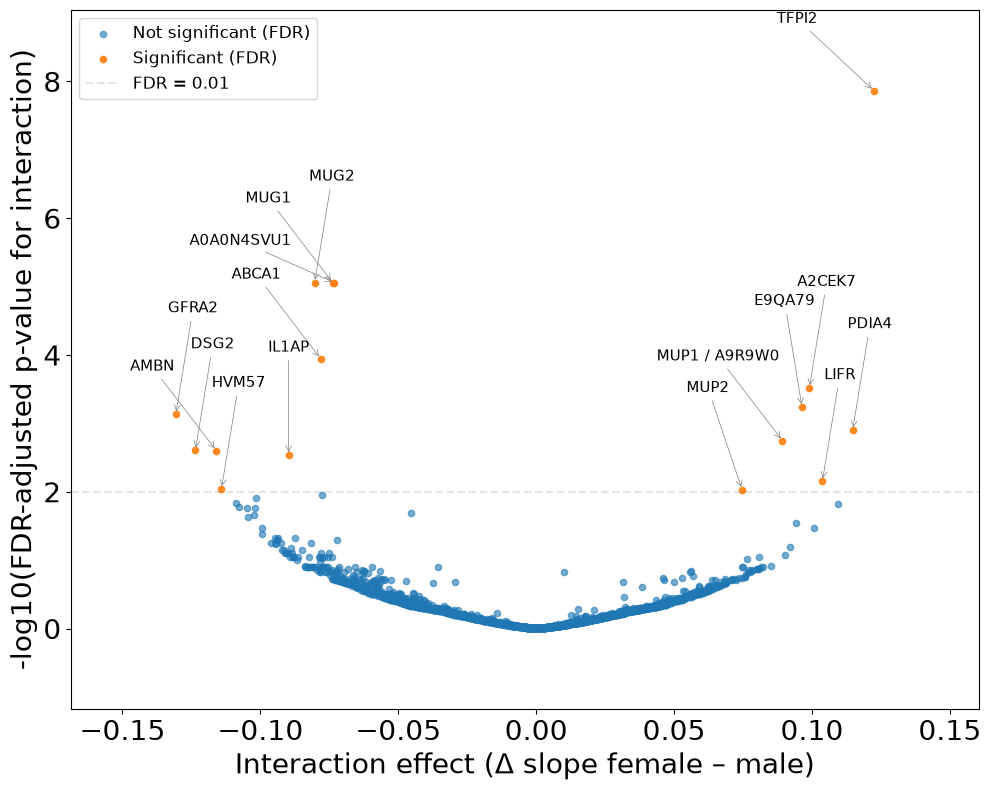

In [9]:
# Visualize results
create_interaction_volcano_plot(
    results,
    top_n=16,
    verbose=False,
    start_radius_px=100,
    max_radius_px=5000,
    radius_step_px=50,
    angle_step_deg=10,
)
plt.show()